# US Superstore — Marketing Strategy Analysis

Mini-project: data analysis to devise a marketing strategy based on **area analysis**, **customer analysis**, **product-category analysis**, and **sales & profit time series**.

**Questions we answer:**
1. Which states have the most sales?
2. Difference between New York and California (total sales & profit)?
3. Who is an outstanding customer in New York?
4. Are there differences among states in profitability?
5. Pareto on customers vs **profit** — do 20% of customers drive 80% of profit?
6. Top 20 cities by Sales and by Profit — profitability differences among cities?
7. Top 20 customers by Sales.
8. Cumulative Sales curve by customers — Pareto on customers vs **sales**?
9. Decision: which states & cities to prioritize for marketing.

## 1. Setup — imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)


In [2]:
# load the dataset from superstore_sales.csv
# the file is latin-1 / ISO-8859-1 encoded (not UTF-8), so we pass encoding explicitly
df = pd.read_csv("superstore_sales.csv", encoding="latin-1")
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Preprocessing

- Standardise column names.
- Parse `Order Date` / `Ship Date` to datetime.
- Inspect dtypes, duplicates and missing values.
- Add helper time columns (Year, Month, YearMonth) and a per-row Profit Margin.

In [3]:
print(df.info())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values per column:\n", df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
# Parse dates (Superstore dates are MM/DD/YYYY)
for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Drop exact duplicates if any
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. New shape: {df.shape}")

# Time helper columns
if "Order Date" in df.columns:
    df["Year"] = df["Order Date"].dt.year
    df["Month"] = df["Order Date"].dt.month
    df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

# Profit margin per row (guard against divide-by-zero)
df["Profit Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)

df.describe(include="all").T

Dropped 0 duplicate rows. New shape: (9994, 21)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-30 00:07:12.259355,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-03 23:06:58.571142,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Q1 — Which states have the most sales?

Top 15 states by total sales:
 State
California        457688.0
New York          310876.0
Texas             170188.0
Washington        138641.0
Pennsylvania      116512.0
Florida            89474.0
Illinois           80166.0
Ohio               78258.0
Michigan           76270.0
Virginia           70637.0
North Carolina     55603.0
Indiana            53555.0
Georgia            49096.0
Kentucky           36592.0
New Jersey         35764.0
Name: Sales, dtype: float64


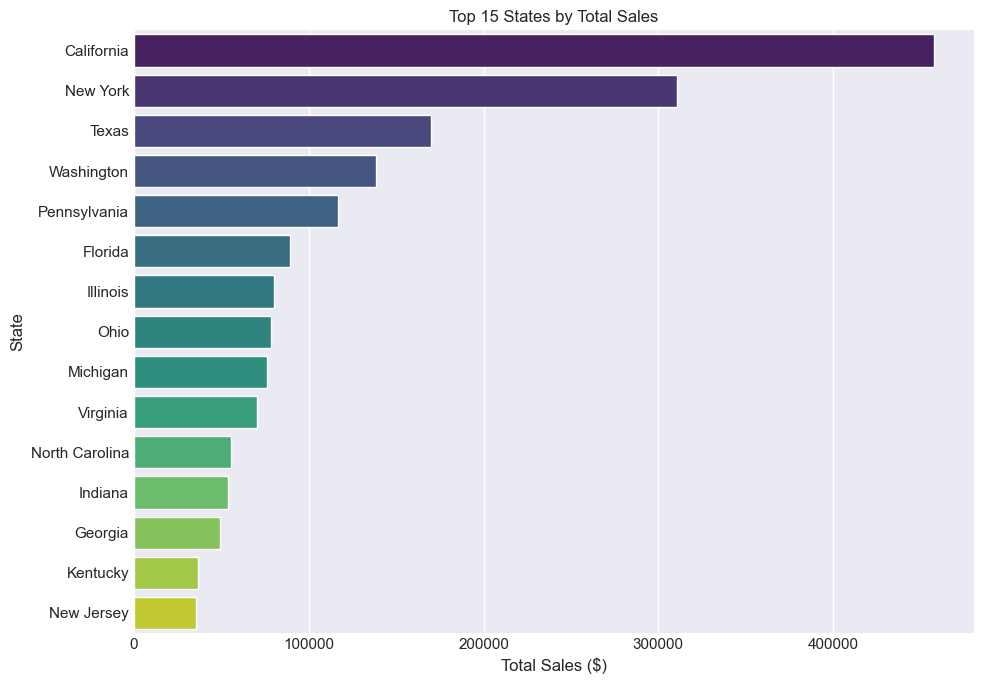

In [5]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
top_states = state_sales.head(15)
print("Top 15 states by total sales:\n", top_states.round(0))

plt.figure(figsize=(10, 7))
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette="viridis", legend=False)
plt.title("Top 15 States by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Observation:** California and New York dominate total sales, followed by Texas, Washington and Pennsylvania.

## 5. Q2 — New York vs California: total sales & profit

                  Sales      Profit  Profit Margin %
State                                               
New York    310876.2710  74038.5486            23.82
California  457687.6315  76381.3871            16.69


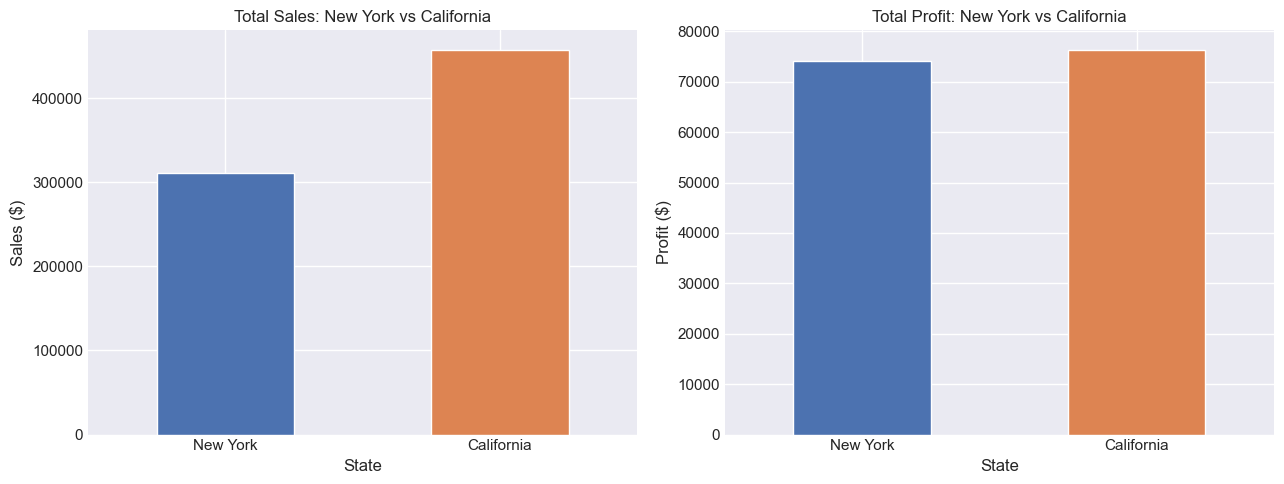

In [6]:
ny_ca = (
    df[df["State"].isin(["New York", "California"])]
    .groupby("State")[["Sales", "Profit"]]
    .sum()
    .reindex(["New York", "California"])
)
ny_ca["Profit Margin %"] = (ny_ca["Profit"] / ny_ca["Sales"] * 100).round(2)
print(ny_ca)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ny_ca["Sales"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Total Sales: New York vs California")
axes[0].set_ylabel("Sales ($)")
ny_ca["Profit"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Total Profit: New York vs California")
axes[1].set_ylabel("Profit ($)")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Observation:** California has the higher absolute sales and profit, but New York typically shows a *higher profit margin* — meaning NY converts each sales dollar into more profit.

## 6. Q3 — Who is an outstanding customer in New York?

Top 10 New York customers by Sales:
                     Sales  Profit
Customer Name                    
Tom Ashbrook      13723.0  4599.0
Peter Fuller       7678.0   543.0
Seth Vernon        7360.0  1572.0
Tom Boeckenhauer   7000.0  2240.0
Greg Tran          6713.0   775.0
Todd Sumrall       6492.0  1575.0
Karen Daniels      6241.0  2283.0
Keith Dawkins      5854.0  2511.0
Luke Weiss         5048.0   773.0
Caroline Jumper    5013.0  1300.0


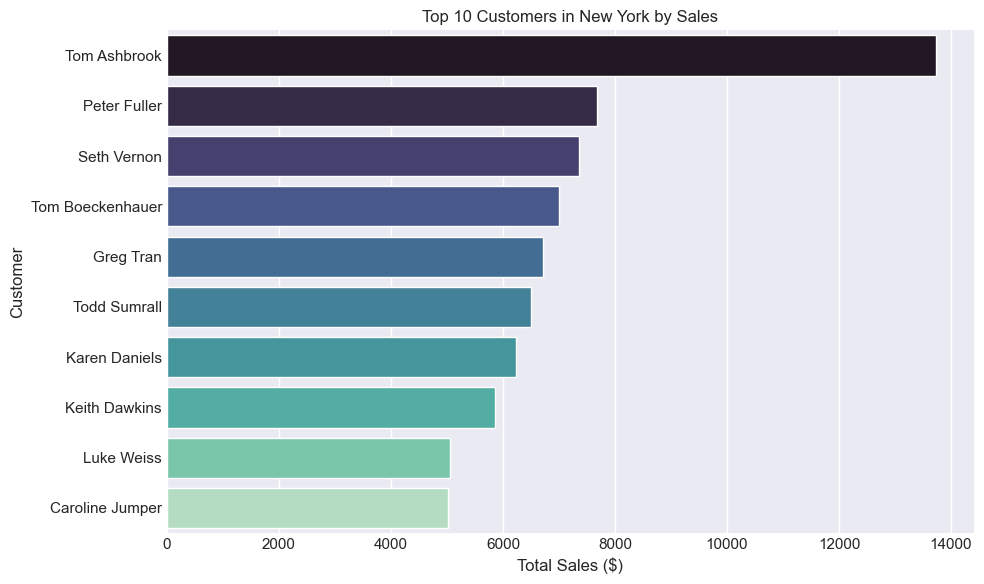


Outstanding NY customer (by sales): Tom Ashbrook
Sales     13723.50
Profit     4599.21
Name: Tom Ashbrook, dtype: float64


In [7]:
ny = df[df["State"] == "New York"]
ny_customers = (
    ny.groupby("Customer Name")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)
print("Top 10 New York customers by Sales:\n", ny_customers.head(10).round(0))

top10_ny = ny_customers.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top10_ny["Sales"], y=top10_ny.index, hue=top10_ny.index, palette="mako", legend=False)
plt.title("Top 10 Customers in New York by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

best_ny = ny_customers.index[0]
print(f"\nOutstanding NY customer (by sales): {best_ny}")
print(ny_customers.loc[best_ny].round(2))

## 7. Q4 — Differences among states in profitability

Profitability is best measured with **profit margin** (Profit / Sales), not just absolute profit. Some high-sales states can even be loss-making.

Most profitable states (by total profit):
                Sales    Profit  Profit Margin %
State                                           
California  457687.63  76381.39            16.69
New York    310876.27  74038.55            23.82
Washington  138641.27  33402.65            24.09
Michigan     76269.61  24463.19            32.07
Virginia     70636.72  18597.95            26.33
Indiana      53555.36  18382.94            34.33
Georgia      49095.84  16250.04            33.10
Kentucky     36591.75  11199.70            30.61
Minnesota    29863.15  10823.19            36.24
Delaware     27451.07   9977.37            36.35

Least profitable / loss-making states (by total profit):
                    Sales    Profit  Profit Margin %
State                                               
Texas           170188.05 -25729.36           -15.12
Ohio             78258.14 -16971.38           -21.69
Pennsylvania    116511.91 -15559.96           -13.35
Illinois         80166.10 -12607.89           -

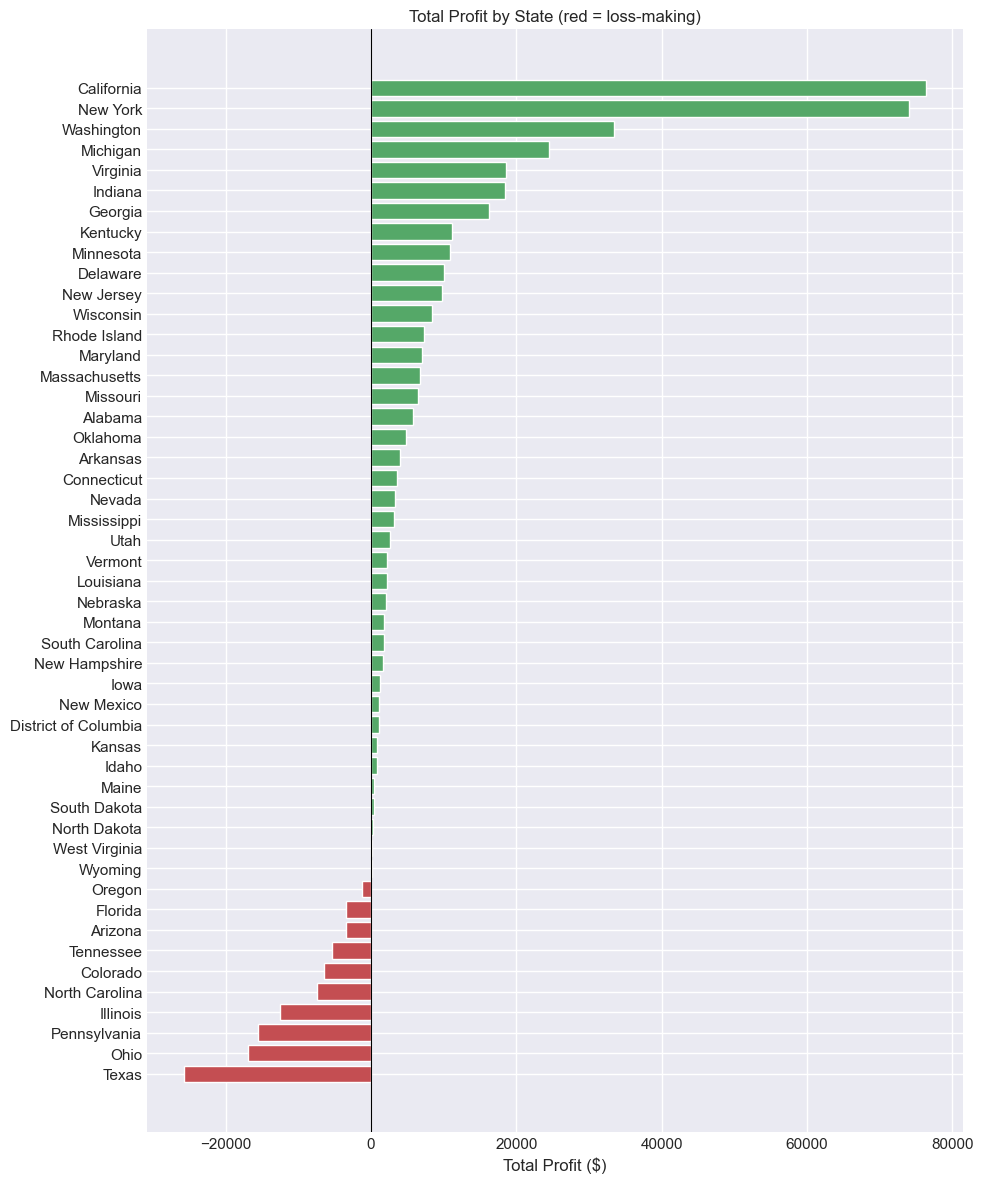

In [8]:
state_perf = df.groupby("State").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
state_perf["Profit Margin %"] = (state_perf["Profit"] / state_perf["Sales"] * 100)

print("Most profitable states (by total profit):")
print(state_perf.sort_values("Profit", ascending=False).head(10).round(2))
print("\nLeast profitable / loss-making states (by total profit):")
print(state_perf.sort_values("Profit").head(10).round(2))

ordered = state_perf.sort_values("Profit")
colors = ["#C44E52" if p < 0 else "#55A868" for p in ordered["Profit"]]
plt.figure(figsize=(10, 12))
plt.barh(ordered.index, ordered["Profit"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Total Profit by State (red = loss-making)")
plt.xlabel("Total Profit ($)")
plt.tight_layout()
plt.show()

**Observation:** Yes — profitability varies sharply. States such as **Texas, Ohio, Pennsylvania and Illinois are net loss-making** (heavy discounting), despite Texas having high sales. California and New York are the strongest profit generators.

## 8. Q5 — Pareto principle: customers vs **Profit**

Do ~20% of customers contribute ~80% of profit?

Top 20% of customers (159 of 793) account for 81.7% of total profit.


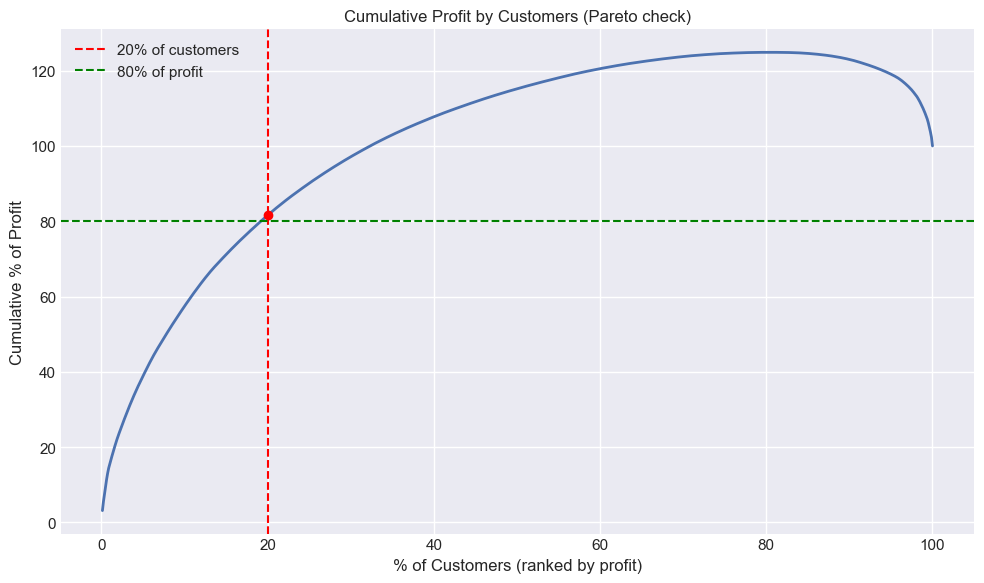

In [9]:
cust_profit = (
    df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)
)
cum_profit = cust_profit.cumsum()
cum_profit_pct = cum_profit / cust_profit.sum() * 100
cust_pct = np.arange(1, len(cust_profit) + 1) / len(cust_profit) * 100

idx20 = int(np.ceil(0.20 * len(cust_profit))) - 1
profit_from_top20 = cum_profit_pct.iloc[idx20]
print(f"Top 20% of customers ({idx20 + 1} of {len(cust_profit)}) "
      f"account for {profit_from_top20:.1f}% of total profit.")

plt.figure(figsize=(10, 6))
plt.plot(cust_pct, cum_profit_pct.values, color="#4C72B0", linewidth=2)
plt.axvline(20, color="red", linestyle="--", label="20% of customers")
plt.axhline(80, color="green", linestyle="--", label="80% of profit")
plt.scatter([20], [profit_from_top20], color="red", zorder=5)
plt.title("Cumulative Profit by Customers (Pareto check)")
plt.xlabel("% of Customers (ranked by profit)")
plt.ylabel("Cumulative % of Profit")
plt.legend()
plt.tight_layout()
plt.show()

**Note:** Because the data contains *loss-making* customers, cumulative profit can exceed 100% before sliding back down. The top 20% of customers generate well **over 80%** of total profit here — the Pareto effect is strong (often even more extreme than 80/20).

## 9. Q6 — Top 20 cities by Sales & by Profit; profitability differences

Top 20 cities by Sales:
                   Sales   Profit  Profit Margin %
City                                             
New York City  256368.0  62037.0             24.0
Los Angeles    175851.0  30441.0             17.0
Seattle        119541.0  29156.0             24.0
San Francisco  112669.0  17507.0             16.0
Philadelphia   109077.0 -13838.0            -13.0
Houston         64505.0 -10154.0            -16.0
Chicago         48540.0  -6655.0            -14.0
San Diego       47521.0   6377.0             13.0
Jacksonville    44713.0  -2324.0             -5.0
Springfield     43054.0   6201.0             14.0
Detroit         42447.0  13182.0             31.0
Columbus        38706.0   5897.0             15.0
Newark          28576.0   5794.0             20.0
Columbia        25283.0   5606.0             22.0
Lafayette       25036.0  10018.0             40.0
Jackson         24964.0   7582.0             30.0
San Antonio     21844.0  -7299.0            -33.0
Burlington      21668.0  

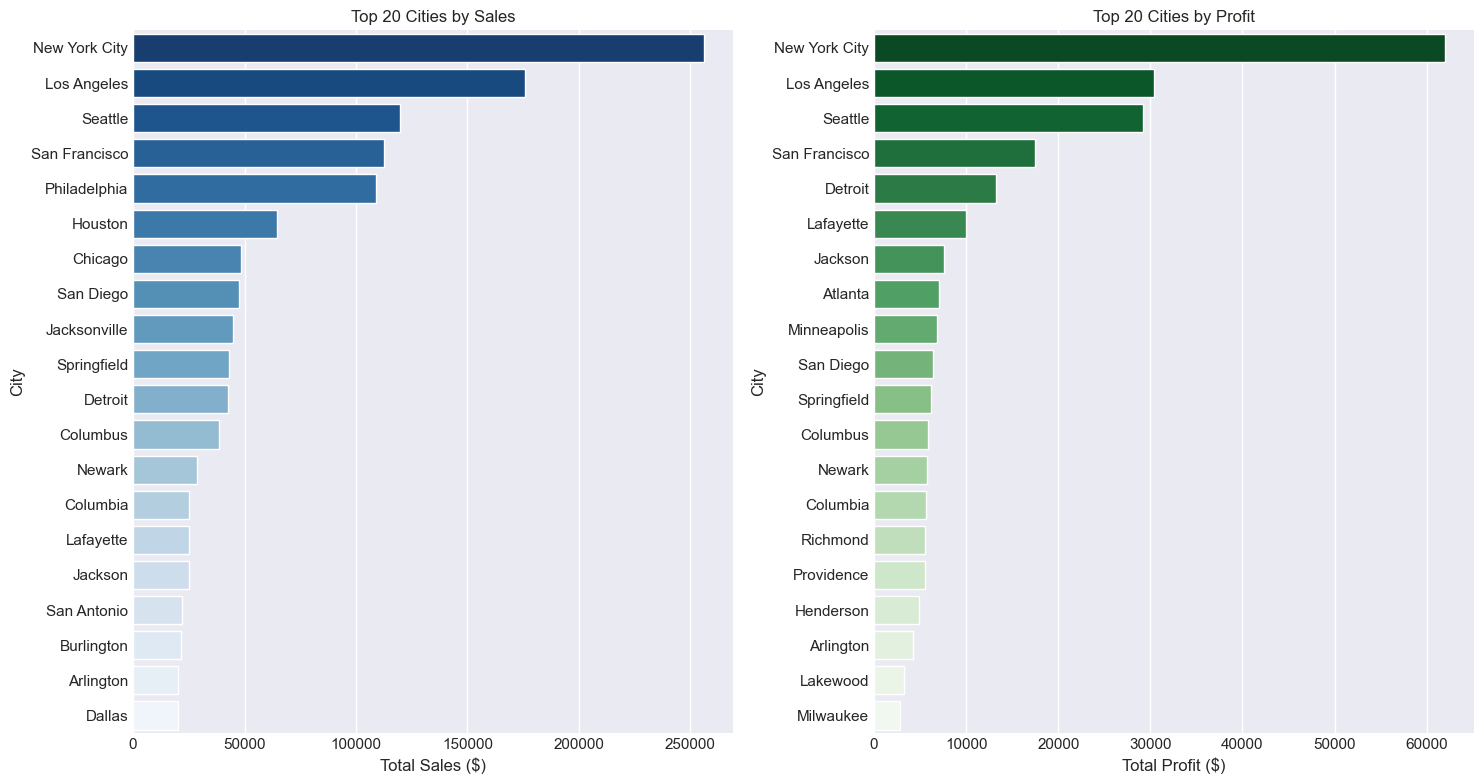

In [10]:
city_perf = df.groupby("City").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
city_perf["Profit Margin %"] = city_perf["Profit"] / city_perf["Sales"] * 100

top20_city_sales = city_perf.sort_values("Sales", ascending=False).head(20)
top20_city_profit = city_perf.sort_values("Profit", ascending=False).head(20)

print("Top 20 cities by Sales:\n", top20_city_sales.round(0))
print("\nTop 20 cities by Profit:\n", top20_city_profit.round(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
sns.barplot(x=top20_city_sales["Sales"], y=top20_city_sales.index,
            hue=top20_city_sales.index, ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Top 20 Cities by Sales")
axes[0].set_xlabel("Total Sales ($)")
sns.barplot(x=top20_city_profit["Profit"], y=top20_city_profit.index,
            hue=top20_city_profit.index, ax=axes[1], palette="Greens_r", legend=False)
axes[1].set_title("Top 20 Cities by Profit")
axes[1].set_xlabel("Total Profit ($)")
plt.tight_layout()
plt.show()

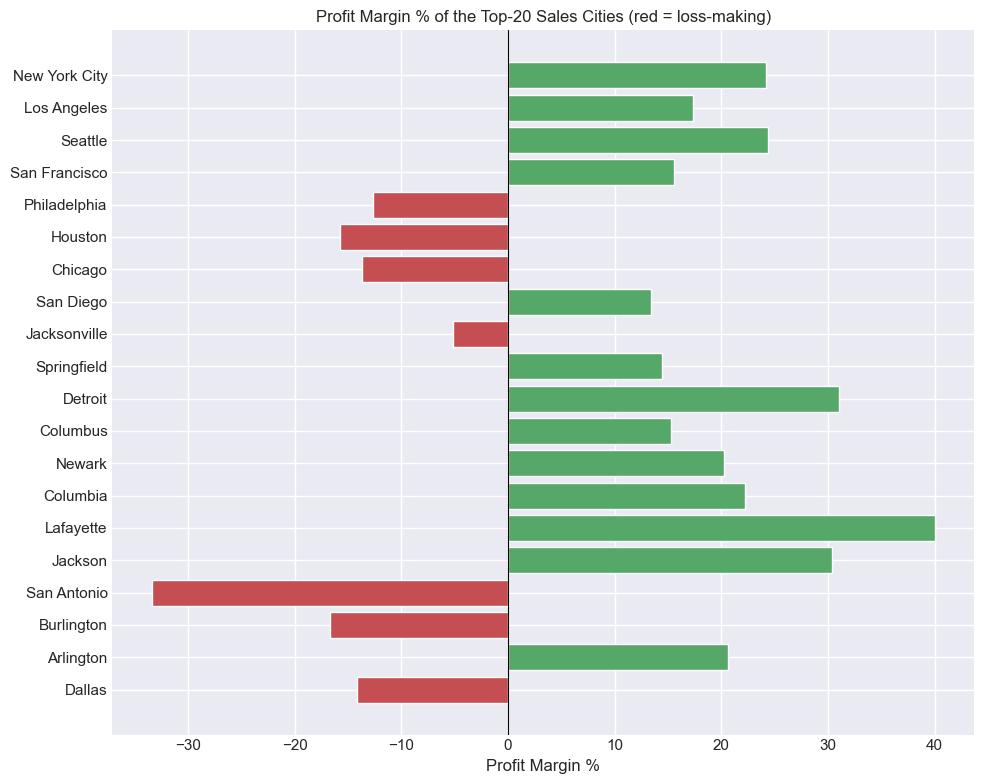

Loss-making cities among the top-20-by-sales:
                  Sales    Profit  Profit Margin %
City                                              
Philadelphia  109077.01 -13837.77           -12.69
Houston        64504.76 -10153.55           -15.74
Chicago        48539.54  -6654.57           -13.71
Jacksonville   44713.18  -2323.84            -5.20
San Antonio    21843.53  -7299.05           -33.42
Burlington     21668.08  -3622.88           -16.72
Dallas         20131.93  -2846.53           -14.14


In [11]:
# Profitability differences among the top-sales cities
plt.figure(figsize=(10, 8))
colors = ["#C44E52" if m < 0 else "#55A868" for m in top20_city_sales["Profit Margin %"]]
plt.barh(top20_city_sales.index, top20_city_sales["Profit Margin %"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Profit Margin % of the Top-20 Sales Cities (red = loss-making)")
plt.xlabel("Profit Margin %")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Loss-making cities among the top-20-by-sales:")
print(top20_city_sales[top20_city_sales["Profit"] < 0][["Sales", "Profit", "Profit Margin %"]].round(2))

**Observation:** High sales ≠ high profit. Cities like **New York City, Los Angeles and Seattle** are both high-sales and high-profit, while some big-sales cities (e.g. **Philadelphia, Houston, Chicago, San Antonio**) are loss-making due to discounting. Profitability differs greatly across cities.

## 10. Q7 — Top 20 customers by Sales

Customer Name
Sean Miller           25043.0
Tamara Chand          19052.0
Raymond Buch          15117.0
Tom Ashbrook          14596.0
Adrian Barton         14474.0
Ken Lonsdale          14175.0
Sanjit Chand          14142.0
Hunter Lopez          12873.0
Sanjit Engle          12209.0
Christopher Conant    12129.0
Todd Sumrall          11892.0
Greg Tran             11820.0
Becky Martin          11790.0
Seth Vernon           11471.0
Caroline Jumper       11165.0
Clay Ludtke           10881.0
Maria Etezadi         10664.0
Karen Ferguson        10604.0
Bill Shonely          10502.0
Edward Hooks          10311.0
Name: Sales, dtype: float64


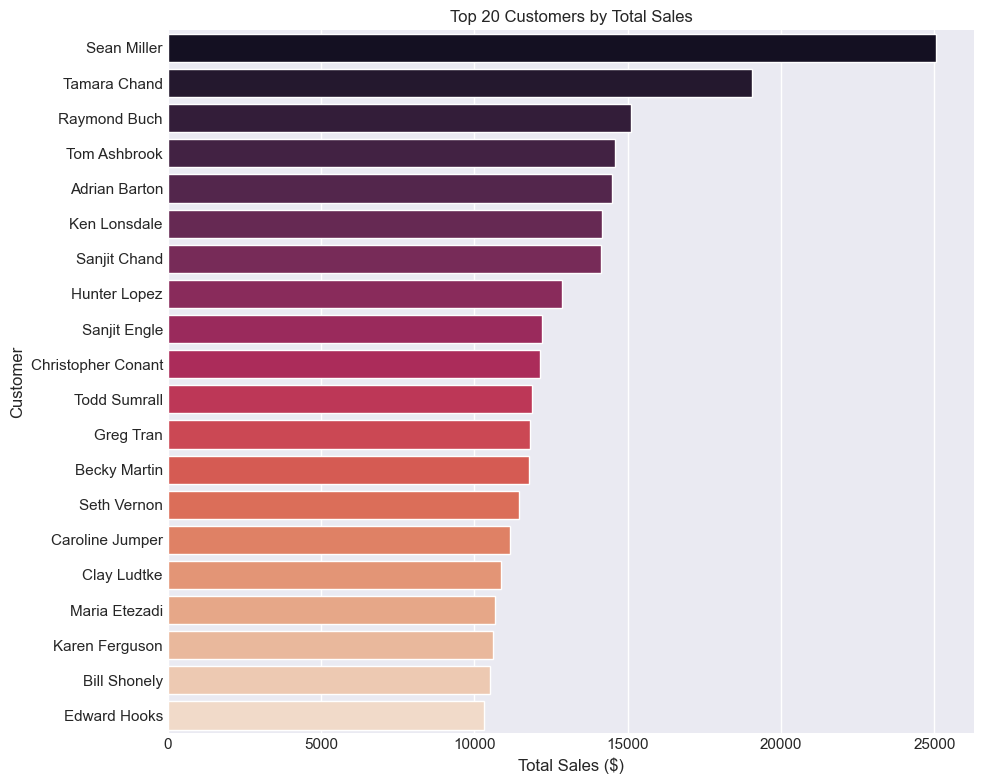

In [12]:
cust_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
top20_cust = cust_sales.head(20)
print(top20_cust.round(0))

plt.figure(figsize=(10, 8))
sns.barplot(x=top20_cust.values, y=top20_cust.index, hue=top20_cust.index, palette="rocket", legend=False)
plt.title("Top 20 Customers by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

## 11. Q8 — Cumulative Sales curve by customers; Pareto on Sales

Top 20% of customers account for 48.1% of total sales.
It takes the top 396 customers (49.9%) to reach 80% of sales.


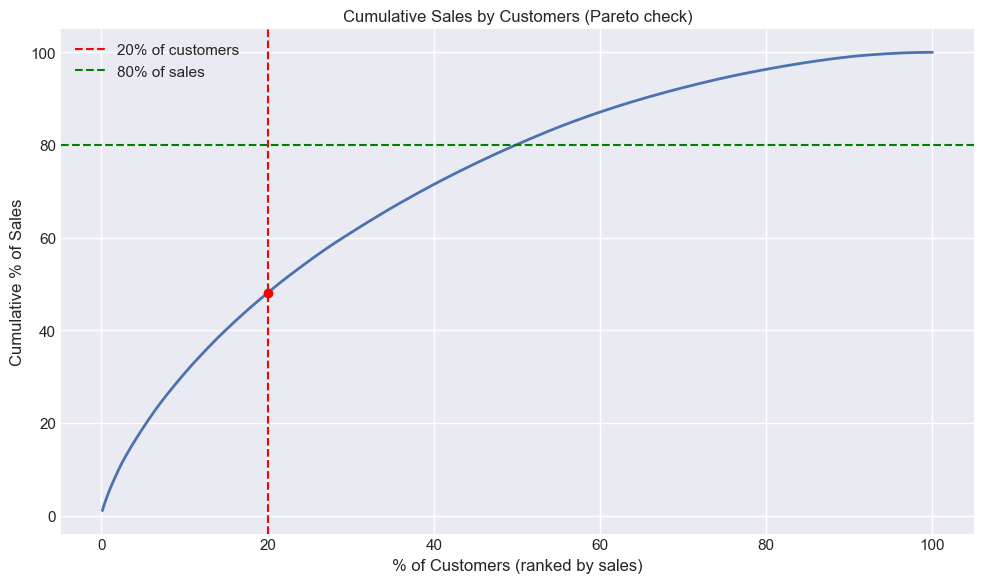

In [13]:
cum_sales_pct = cust_sales.cumsum() / cust_sales.sum() * 100
cust_pct_s = np.arange(1, len(cust_sales) + 1) / len(cust_sales) * 100

idx20_s = int(np.ceil(0.20 * len(cust_sales))) - 1
sales_from_top20 = cum_sales_pct.iloc[idx20_s]
n_for_80 = int((cum_sales_pct <= 80).sum()) + 1
pct_cust_for_80 = n_for_80 / len(cust_sales) * 100

print(f"Top 20% of customers account for {sales_from_top20:.1f}% of total sales.")
print(f"It takes the top {n_for_80} customers ({pct_cust_for_80:.1f}%) to reach 80% of sales.")

plt.figure(figsize=(10, 6))
plt.plot(cust_pct_s, cum_sales_pct.values, color="#4C72B0", linewidth=2)
plt.axvline(20, color="red", linestyle="--", label="20% of customers")
plt.axhline(80, color="green", linestyle="--", label="80% of sales")
plt.scatter([20], [sales_from_top20], color="red", zorder=5)
plt.title("Cumulative Sales by Customers (Pareto check)")
plt.xlabel("% of Customers (ranked by sales)")
plt.ylabel("Cumulative % of Sales")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** For *sales*, the curve is closer to a straight line than for profit — the top 20% of customers contribute roughly **45–55%** of sales, so the classic 80/20 split does **not** hold as cleanly for sales as it does for profit. Sales are spread more evenly across the customer base; profit is far more concentrated.

## 12. Bonus — Sales & Profit over time (time series)

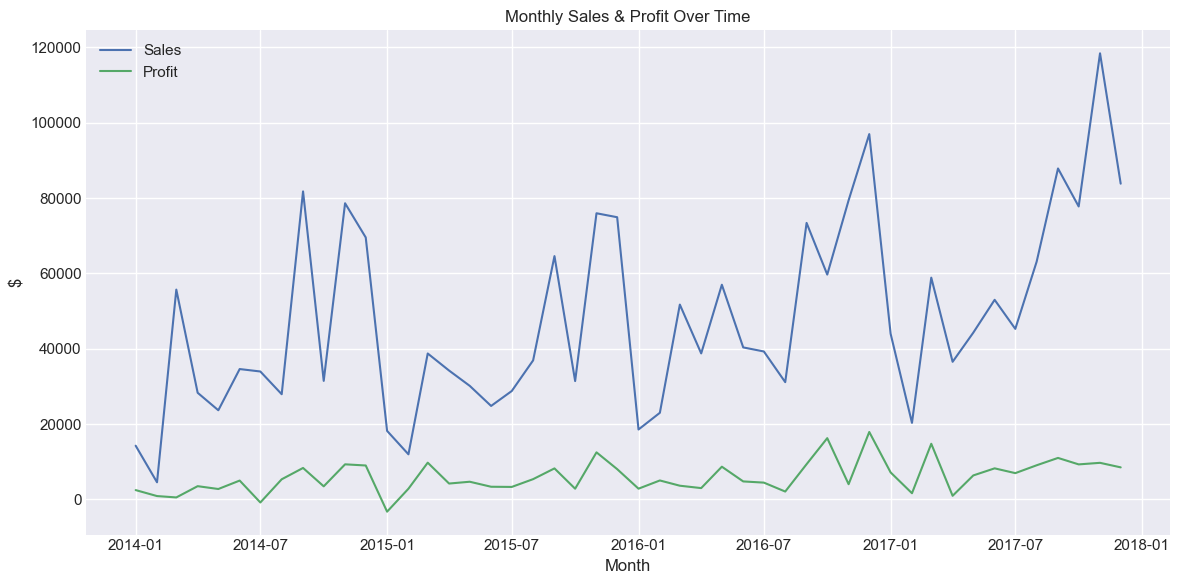

Yearly totals:
          Sales   Profit
Year                   
2014  484247.0  49544.0
2015  470533.0  61619.0
2016  609206.0  81795.0
2017  733215.0  93439.0


In [14]:
if "YearMonth" in df.columns:
    ts = df.groupby("YearMonth")[["Sales", "Profit"]].sum()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ts.index, ts["Sales"], label="Sales", color="#4C72B0")
    ax.plot(ts.index, ts["Profit"], label="Profit", color="#55A868")
    ax.set_title("Monthly Sales & Profit Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("$")
    ax.legend()
    plt.tight_layout()
    plt.show()

    yearly = df.groupby("Year")[["Sales", "Profit"]].sum()
    print("Yearly totals:\n", yearly.round(0))

## 13. Q9 — Decision: states & cities to prioritize

**Findings → strategy**

1. **Sales leaders:** California and New York drive the most sales; Texas, Washington, Pennsylvania follow.
2. **NY vs CA:** California wins on absolute sales/profit; New York wins on profit *margin* (more efficient revenue).
3. **Profitability varies a lot:** several high-sales states/cities (Texas, Pennsylvania, Illinois, Ohio; cities like Philadelphia, Houston, Chicago) are **loss-making**, driven by deep discounts.
4. **Pareto:** profit is highly concentrated — the top ~20% of customers generate the large majority of profit; sales are more evenly distributed.

**Recommendations**

- **Invest / grow marketing in:** California, New York, Washington — high sales *and* healthy margins. Target cities: **New York City, Los Angeles, San Francisco, Seattle**.
- **Fix before scaling (don't pour ad spend yet):** Texas, Pennsylvania, Illinois, Ohio and cities like **Philadelphia, Houston, Chicago, San Antonio** — high volume but negative profit. Review the discount policy here first; growing them as-is grows losses.
- **Protect the profit core:** build retention/loyalty programs for the top ~20% of customers who drive most of the profit.
- **Margin lever:** discounting is the main destroyer of profit — cap or rethink discounts in the loss-making regions/sub-categories before expanding.